In [ ]:
'''
    # 02 - Data Preprocessing Pipeline

    ## 1. Introduction & Objectifs
    - Résumé rapide de l’EDA (déséquilibre, tailles variables...)
    - Objectifs de ce notebook (redimensionnement, normalisation, augmentation)

    ## 2. Configuration & Chemins
    - Définition de `DATA_DIR`
    - Import des bibliothèques (tensorflow.keras, albumentations, etc.)

    ## 3. Calcul des Class Weights
    - Calcul automatique à partir des nombres du train (1341 Normal / 3875 Pneumonia)
    - Explication pourquoi on les utilise

    ## 4. Pipeline de Prétraitement
    - Redimensionnement à 224×224
    - Normalisation (1./255 ou ImageNet statistics ?)
    - Création des générateurs de données

    ## 5. Data Augmentation
    - Configuration de l’augmentation
    - **Stratégie différenciée** : augmentation plus forte sur la classe NORMAL
    - Visualisation d’exemples d’images augmentées (très important pour comprendre)

    ## 6. Création des Data Generators / tf.data Pipeline
    - `ImageDataGenerator` (Keras) ou Albumentations + tf.data
    - Flow from directory avec class_mode='binary'

    ## 7. Test du pipeline
    - Vérifier la shape des batches (32, 224, 224, 3) ou (32, 224, 224, 1)
    - Afficher quelques images augmentées

    ## 8. Conclusion & Décisions
    - Pipeline prêt pour l’entraînement
    - Choix techniques retenus
    - Prochaines étapes (modélisation)

'''

In [ ]:
# ================================================ #
# 1 Introduction & Objectifs                       #
# ================================================ #
'''
    EDA recap : 
        1 - imbalance of samples sizes of classes ['Normal', 'Pneumonia' ] in train split
        2 - diffrence : (1341 Normal / 3875 Pneumonia),  Pneumonia 3 times size of Normal
        
    goals of this norbook :
        1 - resizing
        2 - normalization
        3 - scaling
'''

In [16]:
import tensorflow as tf
import albumentations
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os

# ================================================ #
# 2. Calcul des Class Weights                      #
# ================================================ #

DATA_DIR = "../data/raw/chest_xray"

# Nombres issus de l'EDA (Phase 1)
train_normal     = 1341
train_pneumonia  = 3875
train_total      = train_normal + train_pneumonia
num_classes      = 2

print(f"Train set composition:")
print(f"   Normal    : {train_normal} images ({train_normal/train_total*100:.2f}%)")
print(f"   Pneumonia : {train_pneumonia} images ({train_pneumonia/train_total*100:.2f}%)")
print(f"   Total     : {train_total} images\n")

# ====================== CLASS WEIGHTS ======================
# Formule standard pour compenser le déséquilibre :
# weight_for_class = total_samples / (n_classes * samples_in_class)

weight_normal = train_total / (num_classes * train_normal)
weight_pneumonia = train_total / (num_classes * train_pneumonia)

class_weight = {
    0:weight_normal,
    1:weight_pneumonia
}
print(class_weight)

print("=== Class Weights Calculation ===")
print(f"Weight for NORMAL    : {weight_normal:.4f}")
print(f"Weight for PNEUMONIA : {weight_pneumonia:.4f}")
print(f"Ratio (Normal / Pneumonia) : {weight_normal / weight_pneumonia:.2f}x\n")

Train set composition:
   Normal    : 1341 images (25.71%)
   Pneumonia : 3875 images (74.29%)
   Total     : 5216 images

{0: 1.9448173005219984, 1: 0.6730322580645162}
=== Class Weights Calculation ===
Weight for NORMAL    : 1.9448
Weight for PNEUMONIA : 0.6730
Ratio (Normal / Pneumonia) : 2.89x



In [ ]:
# ====================== EXPLICATION ======================
'''
    Pourquoi utilisons-nous les class weights ?

    Le dataset d'entraînement est fortement déséquilibré (74.29% Pneumonia vs 25.71% Normal).
    Sans compensation, le modèle va minimiser la loss principalement sur la classe majoritaire 
    (Pneumonia), ce qui risque de biaiser les prédictions et de réduire le recall sur la classe Normal.

    Les class weights permettent de donner plus d'importance aux erreurs commises sur la classe 
    minoritaire (Normal) pendant le calcul de la fonction de perte.

    Formule utilisée :
        weight_class_i = total_samples / (n_classes * n_samples_class_i)

    Nous combinerons cette technique avec une data augmentation plus forte sur la classe Normal.
'''

# ====================== UTILISATION FUTURE ======================
'''
    Comment utiliser ces poids pendant l'entraînement ?

    Dans Keras/TensorFlow, nous passerons ce dictionnaire au paramètre class_weight :

        class_weight = {0: weight_normal, 1: weight_pneumonia}

    Exemple dans model.fit():
        model.fit(..., class_weight=class_weight, ...)
'''



In [13]:
# ================================================ #
# 3. Pipeline de Prétraitement                     #
# ================================================ #

# Les modèles de Deep Learning example CNN exigent que toutes les images aient exactement la même taille
# Modèles de Transfer Learning (ResNet50, VGG16, EfficientNet, etc.) :
# Ces modèles ont été entraînés sur ImageNet, où toutes les images sont redimensionnées à 224×224

# 1 Normalisation 1./255

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,              
    rotation_range=15,           
    width_shift_range=0.1,       
    height_shift_range=0.1,      
    zoom_range=0.12,             
    horizontal_flip=True,        
    fill_mode='nearest'          
)

# 2 Création des générateurs de données + Redimensionnement à 224x224
train_generator = train_datagen.flow_from_directory(
    directory=DATA_DIR + "/train",      
    target_size=(224, 224),             
    batch_size=32,
    class_mode='binary',                
    shuffle=True                       
)


Found 5216 images belonging to 2 classes.


In [ ]:
# ================================================ #
# 4. Data Augmentation                             #
# ================================================ #

# ====================== Configuration EXPLICATION ======================
'''
    rescale=1./255 ?
        pixel images are between [0,255] so we normalize them between [0,1] for stable training

    rotation_range=15 ?
        simulate patient positioning variation

    zoom_range=0.12 ?
        simulates different distances

    horizontal_flip=True ?
        lungs are symmetric


    achieved : 
        - improved generalization
        - reduces overfitting


    Nous utilison cette technique pour forcer le model de apprendre les patterns 
    des images et pas memorez les pixel pour minimiser l'error.
    i'l reste le problem de deasquilibre de données.
'''


{'NORMAL': 0, 'PNEUMONIA': 1}


Using original image: ../data/raw/chest_xray/z_test_augmented_version/normal\IM-0115-0001.jpeg


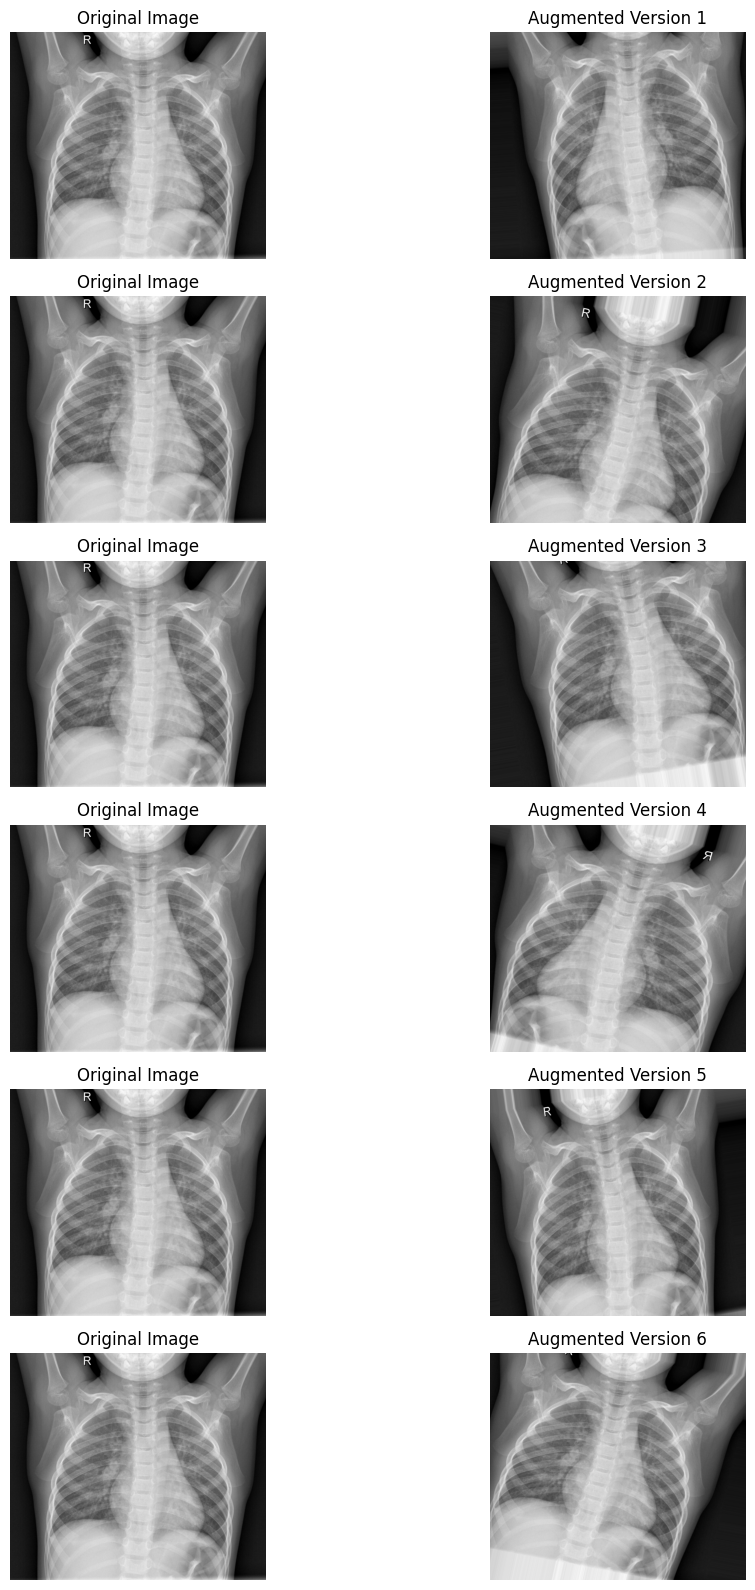

In [14]:
# 2 VISUALIZATION

# Visualisation d’exemples d’images augmentées

# in this example we will use 1 image in ../data/raw/chest_xray/z_test_augmented_version
# to check if augmentation is working or not, if yes we want to see diffrence
# 1 original image on left and 1 augmentation image on right 6 rows 2 columns '6 generated images'

# ================== CONFIG ==================
test_folder = "../data/raw/chest_xray/z_test_augmented_version/normal"

image_files = [f for f in os.listdir(test_folder) if f.lower().endswith(('.jpeg', '.jpg', '.png'))]
if not image_files:
    raise FileNotFoundError(f"No image found in {test_folder}")

original_path = os.path.join(test_folder, image_files[0])
print(f"Using original image: {original_path}")

# Load original image (BGR → RGB)
imgt = cv2.imread(original_path)
if imgt is None:
    raise ValueError(f"Could not read image: {original_path}")

original_img = cv2.cvtColor(imgt, cv2.COLOR_BGR2RGB)   # uint8, 0-255

# ================== AUGMENTATION GENERATOR SINGLE IMAGE ==================
# Important: Do NOT use rescale if we feed already normalized image
aug_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,           
    width_shift_range=0.1,       
    height_shift_range=0.1,      
    zoom_range=0.12,             
    horizontal_flip=True,        
    fill_mode='nearest'
    # rescale=1./255   ← removed here because we normalize manually below
)

# Prepare image for the generator: shape (1, height, width, 3), float32 [0, 1]
img_input = np.expand_dims(original_img.astype(np.float32) / 255.0, axis=0)

# Create generator
aug_generator = aug_datagen.flow(
    img_input,
    batch_size=1,
    shuffle=False,
    seed=42
)

# ================== PLOTTING ==================
fig, axes = plt.subplots(6, 2, figsize=(12, 16))

for i in range(6):
    # Left column: Original (unchanged)
    axes[i, 0].imshow(original_img)
    axes[i, 0].set_title("Original Image")
    axes[i, 0].axis('off')

    # Right column: Augmented
    aug_batch = next(aug_generator)
    aug_img = aug_batch[0]                     # now in [0, 1]

    # Convert to uint8 for display
    aug_display = (aug_img * 255).astype(np.uint8)

    axes[i, 1].imshow(aug_display)
    axes[i, 1].set_title(f"Augmented Version {i+1}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()